# **🎬 Movie Recommendation System – Collaborative Filtering (Item–Item)**

This notebook implements a complete **collaborative filtering–based recommender system** using the **MovieLens 100k dataset**.  
The goal is to understand user–movie interactions, analyze rating patterns, and finally recommend movies similar to a given movie using **Pearson correlation**.

---

## 🔎 **What This Code Does**

### **1️⃣ Loads and Inspects the Dataset**
- Reads the MovieLens ratings file (`.tsv`)
- Applies meaningful column names (`user_id`, `item_id`, `rating`, `timestamp`)
- Loads the movie titles file (`Movie_Id_Titles.csv`)
- Merges titles with ratings using `item_id`
- Displays the first 5 rows of each dataset for verification

---

### **2️⃣ Basic Rating Analysis**
- Computes:
  - **Average rating** for every movie  
  - **Number of ratings** for every movie
- Displays:
  - Top-rated movies  
  - Most-rated movies  
- Builds a summary DataFrame containing:
  - `rating` (mean rating per movie)
  - `num of ratings` (popularity measure)

---

### **3️⃣ Exploratory Data Visualization**
Creates two helpful histograms to understand user behavior:

#### 📊 *Number of Ratings per Movie*
- Shows how many ratings each movie received
- Helps identify popular vs. rarely-rated movies

#### ⭐ *Distribution of Average Ratings*
- Shows how users tend to rate movies overall
- Highlights rating bias patterns

---

### **4️⃣ User–Movie Matrix Creation**
- Builds a **pivot table** with:
  - Rows = `user_id`
  - Columns = `movie titles`
  - Values = user ratings
- This forms the sparse matrix foundation used for collaborative filtering.

Because most users did not rate most movies, this table naturally contains many `NaN` values — this is **normal and expected** in recommender systems.

---

### **5️⃣ Extract Ratings for Specific Movies**
- Selects all user ratings for:
  - **Star Wars (1977)**
  - **Liar Liar (1997)**
- These columns are used as the baseline movies for similarity analysis.

---

### **6️⃣ Movie Similarity Computation (Collaborative Filtering)**
Uses **Pearson correlation** between columns of the user–movie matrix to identify movies that are commonly rated similarly by users.

For each movie:
- `corrwith()` computes correlation with the target movie
- Movies with no shared ratings naturally produce `NaN` and are filtered out
- Joins correlation results with number of ratings for reliability

---

### **7️⃣ Filtering for Reliability**
To avoid noisy correlations:
- Only movies with **more than 100 user ratings** are considered
- This ensures meaningful results and avoids movies with too few interactions

---

### **8️⃣ Final Recommendations**
Outputs two recommendation lists:

#### 🎥 Movies Most Similar to **Star Wars (1977)**
You will typically see other sci-fi classics and adventure movies.

#### 🎭 Movies Most Similar to **Liar Liar (1997)**
Shows comedies and films rated similarly by overlapping users.

The final result is a clean, interpretable collaborative-filtering recommendation list for each selected movie.

---

## 🎯 **Final Outcome**

By the end of this notebook, you will have:

- A merged, structured ratings + titles dataset  
- Visual understanding of user rating patterns  
- A user–movie matrix for collaborative filtering  
- Correlations for similarity-based movie recommendations  
- Two clean recommendation lists filtered by minimum rating counts  

===== Ratings Data (head) =====
   user_id  item_id  rating  timestamp
0        0       50       5  881250949
1        0      172       5  881250949
2        0      133       1  881250949
3      196      242       3  881250949
4      186      302       3  891717742

===== Movie Titles (head) =====
   item_id              title
0        1   Toy Story (1995)
1        2   GoldenEye (1995)
2        3  Four Rooms (1995)
3        4  Get Shorty (1995)
4        5     Copycat (1995)

===== Merged Data (head) =====
   user_id  item_id  rating  timestamp                            title
0        0       50       5  881250949                 Star Wars (1977)
1        0      172       5  881250949  Empire Strikes Back, The (1980)
2        0      133       1  881250949        Gone with the Wind (1939)
3      196      242       3  881250949                     Kolya (1996)
4      186      302       3  891717742         L.A. Confidential (1997)

===== Average Rating per Movie (Top 5) =====
title
They 

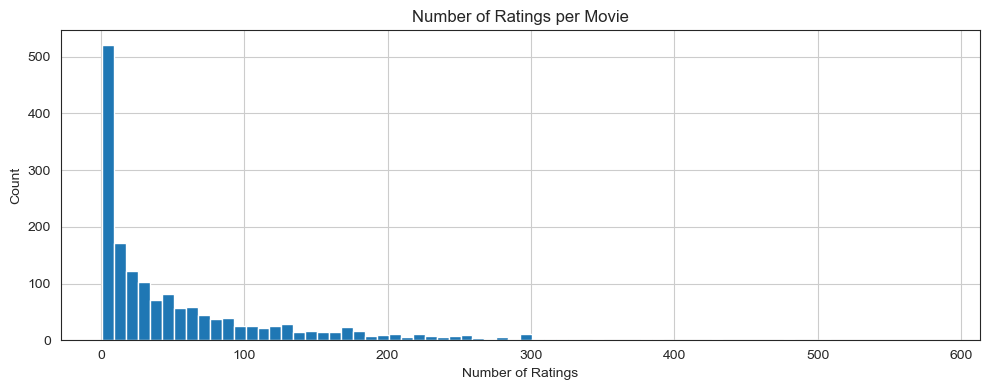

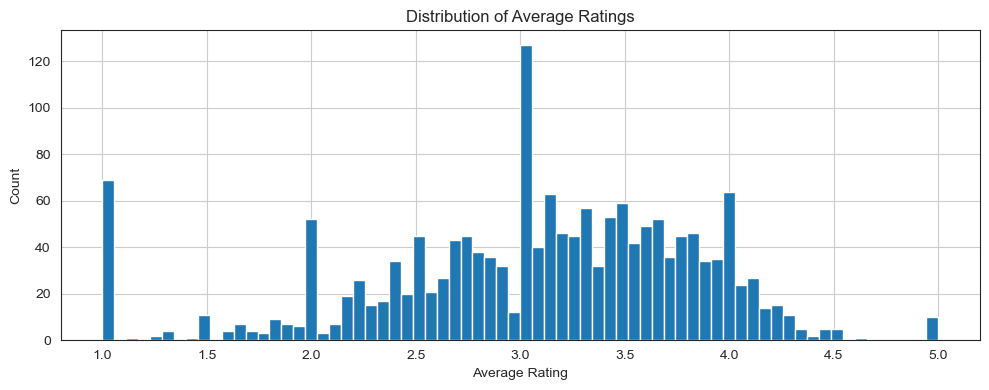


===== User–Movie Matrix (head) =====
title    'Til There Was You (1997)  1-900 (1994)  101 Dalmatians (1996)  \
user_id                                                                   
0                              NaN           NaN                    NaN   
1                              NaN           NaN                    2.0   
2                              NaN           NaN                    NaN   
3                              NaN           NaN                    NaN   
4                              NaN           NaN                    NaN   

title    12 Angry Men (1957)  187 (1997)  2 Days in the Valley (1996)  \
user_id                                                                 
0                        NaN         NaN                          NaN   
1                        5.0         NaN                          NaN   
2                        NaN         NaN                          NaN   
3                        NaN         2.0                          NaN  

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# -----------------------------
# 1. Load Ratings Data (TSV)
# -----------------------------

# Columns in the ratings file (u.data / similar)
column_names = ['user_id', 'item_id', 'rating', 'timestamp']

# TODO: Replace 'file.tsv' with your actual file name, e.g. 'u.data'
path = 'file.tsv'

# Read the ratings data (tab-separated, no header in file, so we pass names=column_names)
df = pd.read_csv(path, sep='\t', names=column_names)

print("===== Ratings Data (head) =====")
print(df.head())

# -----------------------------
# 2. Load Movie Titles
# -----------------------------

# This CSV must contain at least: item_id, title
# Example header: item_id,title
movie_titles = pd.read_csv('Movie_Id_Titles.csv')

print("\n===== Movie Titles (head) =====")
print(movie_titles.head())

# -----------------------------
# 3. Merge Ratings with Titles
# -----------------------------

data = pd.merge(df, movie_titles, on='item_id')

print("\n===== Merged Data (head) =====")
print(data.head())

# -----------------------------
# 4. Basic Aggregations
# -----------------------------

print("\n===== Average Rating per Movie (Top 5) =====")
print(data.groupby('title')['rating'].mean().sort_values(ascending=False).head())

print("\n===== Number of Ratings per Movie (Top 5) =====")
print(data.groupby('title')['rating'].count().sort_values(ascending=False).head())

# -----------------------------
# 5. Ratings DataFrame: mean rating + number of ratings
# -----------------------------

ratings = pd.DataFrame(data.groupby('title')['rating'].mean())
ratings['num of ratings'] = data.groupby('title')['rating'].count()

print("\n===== Ratings DataFrame (head) =====")
print(ratings.head())

# -----------------------------
# 6. Visualization (for scripts, use plt.show())
# -----------------------------

sns.set_style('white')

# Histogram of number of ratings
plt.figure(figsize=(10, 4))
ratings['num of ratings'].hist(bins=70)
plt.title('Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Histogram of average ratings
plt.figure(figsize=(10, 4))
ratings['rating'].hist(bins=70)
plt.title('Distribution of Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Create User–Movie Matrix
# -----------------------------

moviemat = data.pivot_table(index='user_id', columns='title', values='rating')

print("\n===== User–Movie Matrix (head) =====")
print(moviemat.head())

# Top 10 most-rated movies
print("\n===== Top 10 Most-Rated Movies =====")
print(ratings.sort_values('num of ratings', ascending=False).head(10))

# -----------------------------
# 8. Get Ratings for Specific Movies
# -----------------------------

# IMPORTANT: Ensure these titles exist exactly in moviemat.columns
# Otherwise, you'll get a KeyError. You can check with:
# print([c for c in moviemat.columns if 'Star Wars' in c])

if 'Star Wars (1977)' in moviemat.columns:
    starwars_user_ratings = moviemat['Star Wars (1977)']
else:
    raise KeyError("'Star Wars (1977)' not found in moviemat columns. Check your titles in Movie_Id_Titles.csv")

if 'Liar Liar (1997)' in moviemat.columns:
    liarliar_user_ratings = moviemat['Liar Liar (1997)']
else:
    raise KeyError("'Liar Liar (1997)' not found in moviemat columns. Check your titles in Movie_Id_Titles.csv")

print("\n===== Star Wars User Ratings (head) =====")
print(starwars_user_ratings.head())

# -----------------------------
# 9. Compute Correlations with These Movies
# -----------------------------

similar_to_starwars = moviemat.corrwith(starwars_user_ratings)
similar_to_liarliar = moviemat.corrwith(liarliar_user_ratings)

# DataFrame for Star Wars correlations
corr_starwars = pd.DataFrame(similar_to_starwars, columns=['Correlation'])
corr_starwars.dropna(inplace=True)

print("\n===== Raw Correlations with Star Wars (head) =====")
print(corr_starwars.head(10))

# Join with number of ratings to filter out rarely-rated movies
corr_starwars = corr_starwars.join(ratings['num of ratings'])

print("\n===== Correlations with Star Wars + Num of Ratings (head) =====")
print(corr_starwars.head())

print("\n===== Movies Most Similar to Star Wars (min 100 ratings) =====")
print(
    corr_starwars[corr_starwars['num of ratings'] > 100]
    .sort_values('Correlation', ascending=False)
    .head()
)

# DataFrame for Liar Liar correlations
corr_liarliar = pd.DataFrame(similar_to_liarliar, columns=['Correlation'])
corr_liarliar.dropna(inplace=True)

corr_liarliar = corr_liarliar.join(ratings['num of ratings'])

print("\n===== Movies Most Similar to Liar Liar (min 100 ratings) =====")
print(
    corr_liarliar[corr_liarliar['num of ratings'] > 100]
    .sort_values('Correlation', ascending=False)
    .head()
)
